# 🧪 Molecular Toxicity Prediction — Ames Mutagenicity Dataset

**Goal:** Binary classification of molecular mutagenicity using RDKit-computed features and XGBoost.

| Label | Meaning |
|-------|--------|
| `1`   | Toxic (mutagenic) |
| `0`   | Non-toxic |

**Pipeline overview:**
```
SMILES → RDKit Mol → Physicochemical + Structural + Topological Descriptors
                   + Morgan Fingerprint (r=2, 1024 bits)
                   → StandardScaler (descriptors only)
                   → XGBoostClassifier
                   → Evaluation + SHAP Explainability
```

---

## 1. ⚙️ Setup

In [1]:
pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 49.2 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
# ─── Standard Library ──────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')

# ─── Core Data ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── RDKit Cheminformatics ──────────────────────────────────────────────────
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, AllChem, rdMolDescriptors
from rdkit.Chem.GraphDescriptors import BertzCT, BalabanJ
from rdkit.Chem.rdMolDescriptors import CalcTPSA, CalcFractionCSP3, CalcNumHeteroatoms

# Suppress RDKit warnings for invalid SMILES
RDLogger.DisableLog('rdApp.*')

# ─── Machine Learning ──────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)
from xgboost import XGBClassifier
import shap

# ─── Visualisation ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ─── Reproducibility ───────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

# ─── Plot Style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})
sns.set_palette('muted')

print('✅ Environment ready.')
print(f'   NumPy   : {np.__version__}')
print(f'   Pandas  : {pd.__version__}')
import rdkit; print(f'   RDKit   : {rdkit.__version__}')
import xgboost; print(f'   XGBoost : {xgboost.__version__}')
import shap as _s; print(f'   SHAP    : {_s.__version__}')

✅ Environment ready.
   NumPy   : 2.4.6
   Pandas  : 2.3.3
   RDKit   : 2026.03.2
   XGBoost : 3.2.0
   SHAP    : 0.51.0


## 2. 📦 Load Dataset

In [4]:
# ── Configuration ─────────────────────────────────────────────────────────
DATA_PATH   = '/kaggle/input/datasets/heithembenmoussa2/ames-clintox-tox21/combined_toxicity.csv'   # ← UPDATE THIS PATH
SMILES_COL  = 'smiles'
TARGET_COL  = 'Overall'

# ── Load & Select ─────────────────────────────────────────────────────────
raw_df = pd.read_csv(DATA_PATH)

print(f'Raw dataset shape : {raw_df.shape}')
print(f'Columns available : {list(raw_df.columns[:10])} ... (truncated)')

# Keep ONLY the two columns we need — ignore precomputed descriptors
df = raw_df[[SMILES_COL, TARGET_COL]].copy()

# ── Clean ─────────────────────────────────────────────────────────────────
before = len(df)
df.dropna(subset=[SMILES_COL, TARGET_COL], inplace=True)
df[TARGET_COL] = df[TARGET_COL].astype(int)
df = df[df["Overall"] != -1].reset_index(drop=True)
after  = len(df)

print(f'\nRows after dropping NaN : {after}  (removed {before - after})')
print('\nClass distribution:')
vc = df[TARGET_COL].value_counts().sort_index()
for label, cnt in vc.items():
    tag = '(toxic)' if label == 1 else '(non-toxic)'
    print(f'  Label {label} {tag}: {cnt:>5}  ({cnt/len(df)*100:.1f}%)')

df.head(3)

Raw dataset shape : (13209, 2)
Columns available : ['smiles', 'Overall'] ... (truncated)

Rows after dropping NaN : 11969  (removed 1240)

Class distribution:
  Label 0 (non-toxic):  6377  (53.3%)
  Label 1 (toxic):  5592  (46.7%)


,smiles,Overall
0,CCOc1ccc2nc(S(N)(=O)=O)sc2c1,1
1,CCN1C(=O)NC(c2ccccc2)C1=O,0
2,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...,0


## 3. 🔬 RDKit Feature Engineering

In [5]:
# ── Descriptor names (in order) ───────────────────────────────────────────
DESCRIPTOR_NAMES = [
    # Physicochemical
    'MolWt', 'MolLogP', 'TPSA',
    'NumHDonors', 'NumHAcceptors', 'NumRotatableBonds',
    # Structural
    'RingCount', 'FractionCSP3', 'HeavyAtomCount',
    'NumHeteroatoms', 'NumAromaticRings',
    # Topological
    'BertzCT', 'BalabanJ', 'HallKierAlpha',
]

FP_BITS   = 1024
FP_RADIUS = 2
FP_NAMES  = [f'fp_{i}' for i in range(FP_BITS)]
ALL_FEATURE_NAMES = DESCRIPTOR_NAMES + FP_NAMES


def smiles_to_mol(smiles: str):
    """Safely convert a SMILES string to an RDKit Mol object."""
    if not isinstance(smiles, str) or not smiles.strip():
        return None
    mol = Chem.MolFromSmiles(smiles)
    return mol  # None if invalid


def mol_to_descriptors(mol) -> np.ndarray:
    """
    Compute 14 RDKit descriptors from a valid Mol object.
    Returns a float32 array of shape (14,).
    """
    try:
        desc = np.array([
            # ── Physicochemical ──────────────────────────────────────────
            Descriptors.MolWt(mol),
            Descriptors.MolLogP(mol),
            CalcTPSA(mol),
            rdMolDescriptors.CalcNumHBD(mol),      # H-bond donors
            rdMolDescriptors.CalcNumHBA(mol),      # H-bond acceptors
            rdMolDescriptors.CalcNumRotatableBonds(mol),
            # ── Structural ───────────────────────────────────────────────
            rdMolDescriptors.CalcNumRings(mol),
            CalcFractionCSP3(mol),
            Descriptors.HeavyAtomCount(mol),
            CalcNumHeteroatoms(mol),
            rdMolDescriptors.CalcNumAromaticRings(mol),
            # ── Topological ──────────────────────────────────────────────
            BertzCT(mol),
            BalabanJ(mol),
            Descriptors.HallKierAlpha(mol),
        ], dtype=np.float32)
        return desc
    except Exception:
        return np.full(len(DESCRIPTOR_NAMES), np.nan, dtype=np.float32)


def mol_to_morgan_fp(mol) -> np.ndarray:
    """
    Compute Morgan fingerprint (ECFP4) as a binary numpy array.
    Returns a uint8 array of shape (FP_BITS,).
    """
    try:
        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol, radius=FP_RADIUS, nBits=FP_BITS
        )
        arr = np.zeros(FP_BITS, dtype=np.uint8)
        fp.GetOnBits()
        for bit in fp.GetOnBits():
            arr[bit] = 1
        return arr
    except Exception:
        return np.zeros(FP_BITS, dtype=np.uint8)


def featurise_smiles_series(smiles_series: pd.Series):
    """
    Compute full feature matrix from a Series of SMILES strings.

    Returns
    -------
    valid_mask  : boolean array  (True = successfully parsed)
    descriptors : float32 array  (N_valid × 14)
    fingerprints: uint8   array  (N_valid × FP_BITS)
    """
    n = len(smiles_series)
    desc_matrix = np.full((n, len(DESCRIPTOR_NAMES)), np.nan, dtype=np.float32)
    fp_matrix   = np.zeros((n, FP_BITS), dtype=np.uint8)
    valid_mask  = np.zeros(n, dtype=bool)

    for idx, smiles in enumerate(smiles_series):
        mol = smiles_to_mol(smiles)
        if mol is None:
            continue
        desc = mol_to_descriptors(mol)
        if np.isnan(desc).any():
            continue
        desc_matrix[idx] = desc
        fp_matrix[idx]   = mol_to_morgan_fp(mol)
        valid_mask[idx]  = True

    return valid_mask, desc_matrix, fp_matrix


print('🔬 Computing RDKit features …')
valid_mask, desc_matrix, fp_matrix = featurise_smiles_series(df[SMILES_COL])

n_invalid = (~valid_mask).sum()
print(f'   Total molecules   : {len(df)}')
print(f'   Invalid SMILES    : {n_invalid}  ({n_invalid/len(df)*100:.1f}%)')
print(f'   Valid molecules   : {valid_mask.sum()}')
print(f'   Descriptor shape  : {desc_matrix[valid_mask].shape}')
print(f'   Fingerprint shape : {fp_matrix[valid_mask].shape}')

🔬 Computing RDKit features …
   Total molecules   : 11969
   Invalid SMILES    : 12  (0.1%)
   Valid molecules   : 11957
   Descriptor shape  : (11957, 14)
   Fingerprint shape : (11957, 1024)


## 4. 🏗️ Feature Matrix Construction

In [7]:
# Filter to valid molecules only
X_desc = desc_matrix[valid_mask]          # (N, 14)    float32
X_fp   = fp_matrix[valid_mask]            # (N, 1024)  uint8
y      = df[TARGET_COL].values[valid_mask] # (N,)       int

# Concatenate descriptors + fingerprint bits into one feature matrix
X = np.hstack([X_desc, X_fp.astype(np.float32)])  # (N, 14 + 1024)

assert X.shape[1] == len(DESCRIPTOR_NAMES) + FP_BITS, \
    f'Feature dimension mismatch: got {X.shape[1]}'
assert len(y) == X.shape[0], 'Sample count mismatch between X and y!'

# Build a DataFrame for reference
X_df = pd.DataFrame(X, columns=ALL_FEATURE_NAMES)

print(f'✅ Feature matrix ready')
print(f'   Shape            : {X.shape}')
print(f'   Descriptor cols  : {len(DESCRIPTOR_NAMES)}')
print(f'   Fingerprint cols : {FP_BITS}')
print(f'   Total features   : {X.shape[1]}')
print(f'\nClass balance in valid set:')
vc = pd.Series(y).value_counts().sort_index()
for lbl, cnt in vc.items():
    print(f'  {lbl}: {cnt} ({cnt/len(y)*100:.1f}%)')

X_df[DESCRIPTOR_NAMES].describe().T.round(3)

✅ Feature matrix ready
   Shape            : (11957, 1038)
   Descriptor cols  : 14
   Fingerprint cols : 1024
   Total features   : 1038

Class balance in valid set:
  0: 6368 (53.3%)
  1: 5589 (46.7%)


,count,mean,std,min,25%,50%,75%,max
MolWt,11957.0,285.604,171.605,9.012,178.260,253.269,342.855,2045.331
MolLogP,11957.0,2.321,2.400,-19.396,1.084,2.374,3.690,22.612
TPSA,11957.0,64.512,63.215,0.000,26.790,52.040,83.220,833.780
NumHDonors,11957.0,1.300,2.032,0.000,0.000,1.000,2.000,30.000
NumHAcceptors,11957.0,3.652,3.285,0.000,2.000,3.000,5.000,51.000
NumRotatableBonds,11957.0,4.075,4.514,0.000,1.000,3.000,6.000,55.000
RingCount,11957.0,2.074,1.740,0.000,1.000,2.000,3.000,30.000
FractionCSP3,11957.0,0.412,0.322,0.000,0.133,0.364,0.667,1.000
HeavyAtomCount,11957.0,19.420,11.807,1.000,12.000,17.000,24.000,145.000
NumHeteroatoms,11957.0,5.199,4.315,0.000,3.000,4.000,7.000,67.000


## 5. ✂️ Train / Validation / Test Split

In [8]:
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15   # of total
TEST_RATIO  = 0.15   # of total

# Step 1: split off the test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=TEST_RATIO,
    stratify=y,
    random_state=RANDOM_SEED
)

# Step 2: split the remaining 85% into train (70%) and val (15%)
val_ratio_of_temp = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)  # ≈ 0.1765
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_ratio_of_temp,
    stratify=y_temp,
    random_state=RANDOM_SEED
)

total = len(X)
print('📊 Dataset splits (stratified):')
print(f'   Train : {len(X_train):>5} samples  ({len(X_train)/total*100:.1f}%)')
print(f'   Val   : {len(X_val):>5} samples  ({len(X_val)/total*100:.1f}%)')
print(f'   Test  : {len(X_test):>5} samples  ({len(X_test)/total*100:.1f}%)')

def class_ratio(arr):
    vc = pd.Series(arr).value_counts().sort_index()
    return {k: f'{v} ({v/len(arr)*100:.1f}%)' for k, v in vc.items()}

print('\nClass distribution per split:')
for name, yy in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f'   {name}: {class_ratio(yy)}')

📊 Dataset splits (stratified):
   Train :  8369 samples  (70.0%)
   Val   :  1794 samples  (15.0%)
   Test  :  1794 samples  (15.0%)

Class distribution per split:
   Train: {0: '4457 (53.3%)', 1: '3912 (46.7%)'}
   Val: {0: '956 (53.3%)', 1: '838 (46.7%)'}
   Test: {0: '955 (53.2%)', 1: '839 (46.8%)'}


## 6. 🔧 Preprocessing

In [10]:
# Number of continuous descriptor columns
N_DESC = len(DESCRIPTOR_NAMES)   # 14

# Fit scaler ONLY on training descriptor columns
scaler = StandardScaler()
scaler.fit(X_train[:, :N_DESC])

def apply_preprocessing(X_split, is_train=False):
    """
    Scale the continuous descriptor block; leave fingerprint bits as-is.
    """
    X_out = X_split.copy().astype(np.float32)
    X_out[:, :N_DESC] = scaler.transform(X_split[:, :N_DESC])
    # Fingerprint columns (N_DESC:) remain [0, 1] binary — no scaling needed
    return X_out

X_train_pp = apply_preprocessing(X_train)
X_val_pp   = apply_preprocessing(X_val)
X_test_pp  = apply_preprocessing(X_test)

print('✅ Preprocessing applied')
print(f'   Scaled  : columns 0 – {N_DESC-1} (physicochemical / structural / topological)')
print(f'   Unscaled: columns {N_DESC} – {N_DESC + FP_BITS - 1} (Morgan fingerprint bits)')
print(f'\n   X_train_pp shape : {X_train_pp.shape}')
print(f'   X_val_pp   shape : {X_val_pp.shape}')
print(f'   X_test_pp  shape : {X_test_pp.shape}')

# Quick sanity: scaled descriptor means should be near 0 on train
desc_means = X_train_pp[:, :N_DESC].mean(axis=0).round(3)
print(f'\n   Descriptor column means (train) — should be ~0:')
print('  ', dict(zip(DESCRIPTOR_NAMES, desc_means)))

✅ Preprocessing applied
   Scaled  : columns 0 – 13 (physicochemical / structural / topological)
   Unscaled: columns 14 – 1037 (Morgan fingerprint bits)

   X_train_pp shape : (8369, 1038)
   X_val_pp   shape : (1794, 1038)
   X_test_pp  shape : (1794, 1038)

   Descriptor column means (train) — should be ~0:
   {'MolWt': np.float32(-0.0), 'MolLogP': np.float32(0.0), 'TPSA': np.float32(0.0), 'NumHDonors': np.float32(-0.0), 'NumHAcceptors': np.float32(-0.0), 'NumRotatableBonds': np.float32(-0.0), 'RingCount': np.float32(-0.0), 'FractionCSP3': np.float32(-0.0), 'HeavyAtomCount': np.float32(0.0), 'NumHeteroatoms': np.float32(0.0), 'NumAromaticRings': np.float32(-0.0), 'BertzCT': np.float32(-0.0), 'BalabanJ': np.float32(0.0), 'HallKierAlpha': np.float32(-0.0)}


## 7. 🚀 Model Training — XGBoostClassifier

In [11]:
from xgboost import callback as xgb_callback

# ── Compute scale_pos_weight for class imbalance ──────────────────────────
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f'Class balance: neg={neg}, pos={pos}  → scale_pos_weight={scale_pos_weight:.3f}')

# ── Model definition ──────────────────────────────────────────────────────
model = XGBClassifier(
    # Architecture
    n_estimators          = 500,
    max_depth             = 6,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 3,
    gamma                 = 0.1,
    reg_alpha             = 0.1,    # L1
    reg_lambda            = 1.0,    # L2
    # Class imbalance
    scale_pos_weight      = scale_pos_weight,
    # Training
    objective             = 'binary:logistic',
    eval_metric           = ['logloss', 'auc'],
    early_stopping_rounds = 30,
    n_jobs                = -1,
    random_state          = RANDOM_SEED,
    verbosity             = 1,
)

# ── Training with early stopping on validation AUC ────────────────────────
print('\n🚀 Training XGBoost …')
model.fit(
    X_train_pp, y_train,
    eval_set    = [(X_train_pp, y_train), (X_val_pp, y_val)],
    verbose     = 25,                  # log every 25 rounds
)

best_iter = model.best_iteration
print(f'\n✅ Training complete. Best iteration: {best_iter}')

Class balance: neg=4457, pos=3912  → scale_pos_weight=1.139

🚀 Training XGBoost …
[0]	validation_0-logloss:0.68178	validation_0-auc:0.76998	validation_1-logloss:0.68209	validation_1-auc:0.76412
[25]	validation_0-logloss:0.53238	validation_0-auc:0.85604	validation_1-logloss:0.55445	validation_1-auc:0.81513
[50]	validation_0-logloss:0.48147	validation_0-auc:0.87677	validation_1-logloss:0.52240	validation_1-auc:0.82277
[75]	validation_0-logloss:0.45407	validation_0-auc:0.89027	validation_1-logloss:0.50715	validation_1-auc:0.82959
[100]	validation_0-logloss:0.43488	validation_0-auc:0.90095	validation_1-logloss:0.50017	validation_1-auc:0.83211
[125]	validation_0-logloss:0.42187	validation_0-auc:0.90822	validation_1-logloss:0.49580	validation_1-auc:0.83433
[150]	validation_0-logloss:0.40868	validation_0-auc:0.91505	validation_1-logloss:0.49265	validation_1-auc:0.83538
[175]	validation_0-logloss:0.39801	validation_0-auc:0.92108	validation_1-logloss:0.48981	validation_1-auc:0.83659
[200]	valid

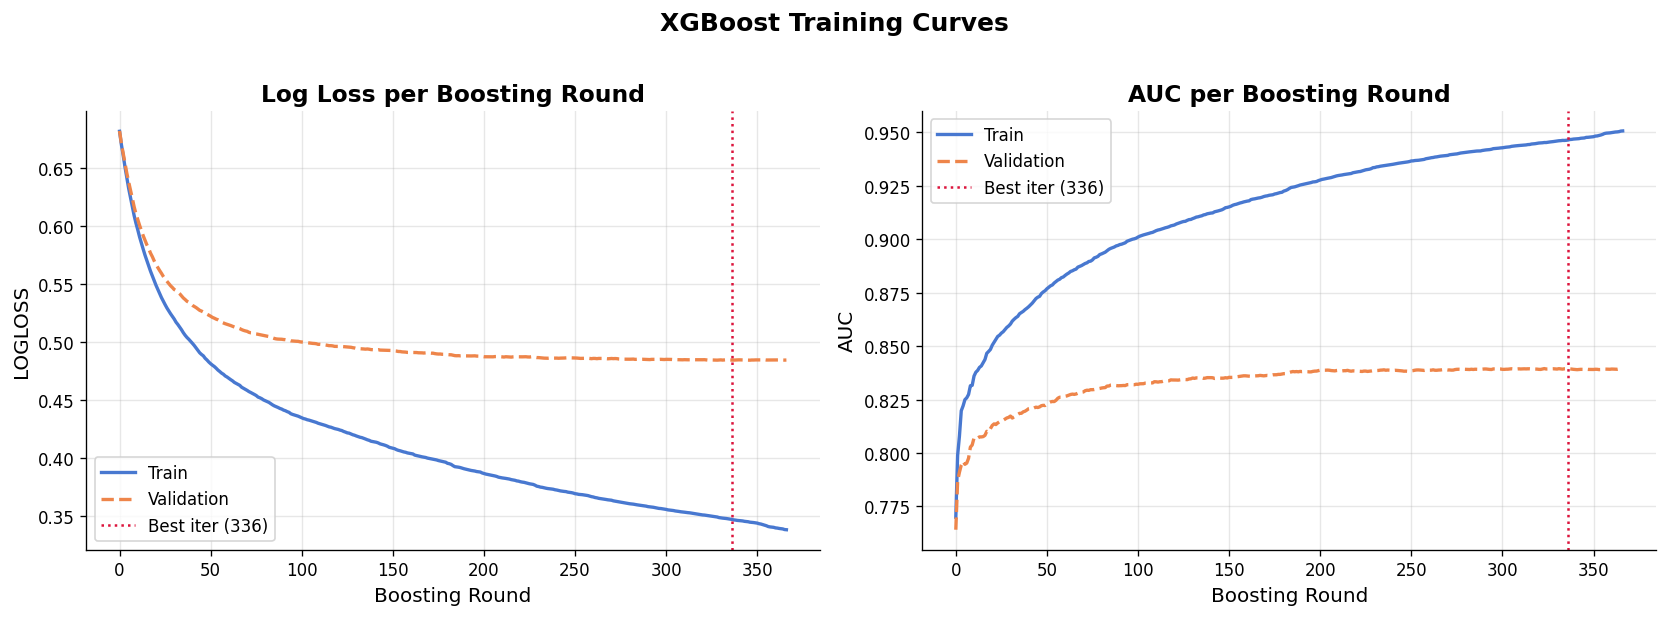

In [12]:
# ── Plot training curves ───────────────────────────────────────────────────
results = model.evals_result()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(
    axes,
    ['logloss', 'auc'],
    ['Log Loss per Boosting Round', 'AUC per Boosting Round']
):
    ax.plot(results['validation_0'][metric], label='Train', linewidth=2)
    ax.plot(results['validation_1'][metric], label='Validation', linewidth=2, linestyle='--')
    ax.axvline(best_iter, color='crimson', linestyle=':', linewidth=1.5,
               label=f'Best iter ({best_iter})')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Boosting Round')
    ax.set_ylabel(metric.upper())
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('XGBoost Training Curves', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 📊 Evaluation on Test Set

In [13]:
# ── Predictions ────────────────────────────────────────────────────────────
y_pred_prob = model.predict_proba(X_test_pp)[:, 1]   # P(toxic)
y_pred      = model.predict(X_test_pp)

# ── Metrics ────────────────────────────────────────────────────────────────
metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall'   : recall_score(y_test, y_pred, zero_division=0),
    'F1-Score' : f1_score(y_test, y_pred, zero_division=0),
    'ROC-AUC'  : roc_auc_score(y_test, y_pred_prob),
}

print('=' * 45)
print('         TEST SET EVALUATION RESULTS')
print('=' * 45)
for k, v in metrics.items():
    bar = '█' * int(v * 25)
    print(f'  {k:<12}: {v:.4f}  {bar}')
print('=' * 45)

print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred,
                            target_names=['Non-toxic (0)', 'Toxic (1)']))

         TEST SET EVALUATION RESULTS
  Accuracy    : 0.7692  ███████████████████
  Precision   : 0.7707  ███████████████████
  Recall      : 0.7211  ██████████████████
  F1-Score    : 0.7451  ██████████████████
  ROC-AUC     : 0.8466  █████████████████████

Detailed Classification Report:
               precision    recall  f1-score   support

Non-toxic (0)       0.77      0.81      0.79       955
    Toxic (1)       0.77      0.72      0.75       839

     accuracy                           0.77      1794
    macro avg       0.77      0.77      0.77      1794
 weighted avg       0.77      0.77      0.77      1794



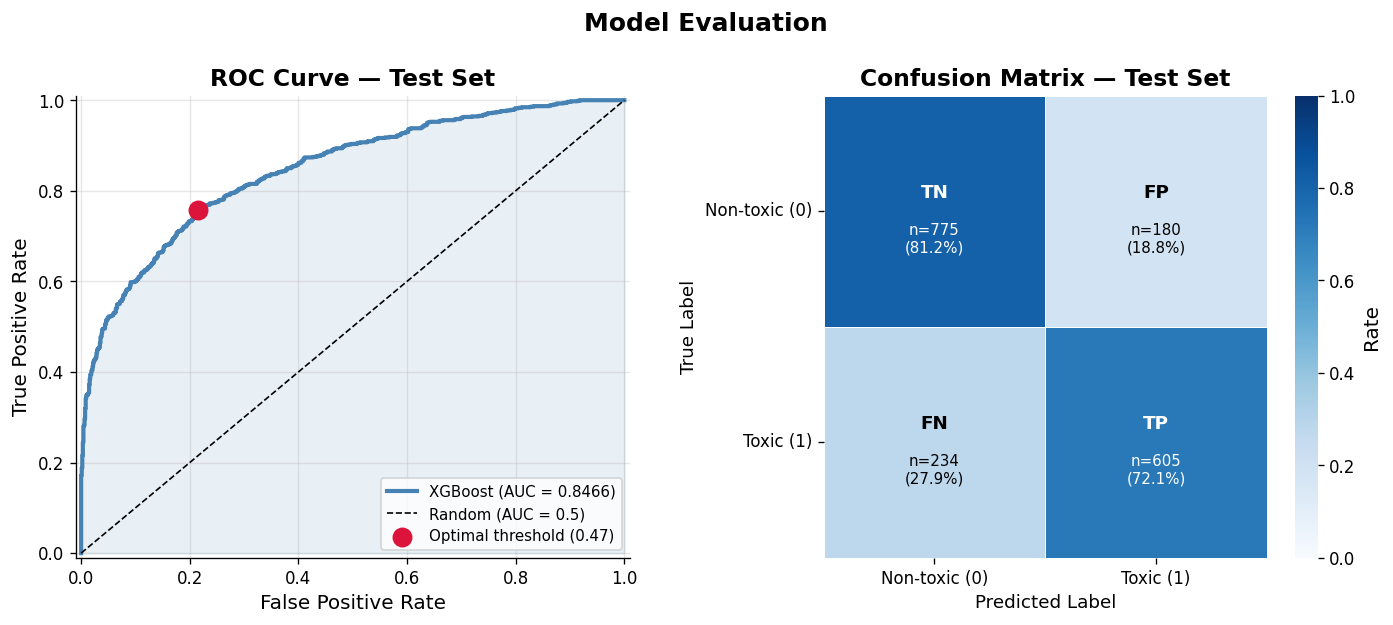


💡 Youden-optimal classification threshold: 0.4670


In [14]:
# ── Figure: ROC curve + Confusion matrix ──────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_val = metrics['ROC-AUC']
cm      = confusion_matrix(y_test, y_pred)

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# ── ROC Curve ─────────────────────────────────────────────────────────────
ax_roc = fig.add_subplot(gs[0])
ax_roc.plot(fpr, tpr, color='steelblue', linewidth=2.5,
            label=f'XGBoost (AUC = {auc_val:.4f})')
ax_roc.fill_between(fpr, tpr, alpha=0.12, color='steelblue')
ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve — Test Set', fontweight='bold')
ax_roc.legend(loc='lower right')
ax_roc.grid(alpha=0.3)
ax_roc.set_xlim([-0.01, 1.01])
ax_roc.set_ylim([-0.01, 1.01])

# Annotate best threshold
youden_idx = np.argmax(tpr - fpr)
best_thresh = thresholds[youden_idx]
ax_roc.scatter(fpr[youden_idx], tpr[youden_idx], s=120, zorder=5,
               color='crimson', label=f'Optimal threshold ({best_thresh:.2f})')
ax_roc.legend(loc='lower right', fontsize=9)

# ── Confusion Matrix ──────────────────────────────────────────────────────
ax_cm = fig.add_subplot(gs[1])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

sns.heatmap(
    cm_norm, annot=False, fmt='', cmap='Blues',
    ax=ax_cm, linewidths=0.5, linecolor='white',
    vmin=0, vmax=1, cbar_kws={'label': 'Rate'}
)

# Annotate cells with count + rate
labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        color = 'white' if cm_norm[i, j] > 0.5 else 'black'
        ax_cm.text(
            j + 0.5, i + 0.42,
            f'{labels[i][j]}',
            ha='center', va='center', fontsize=11,
            fontweight='bold', color=color
        )
        ax_cm.text(
            j + 0.5, i + 0.62,
            f'n={cm[i, j]}\n({cm_norm[i, j]*100:.1f}%)',
            ha='center', va='center', fontsize=9, color=color
        )

ax_cm.set_xticklabels(['Non-toxic (0)', 'Toxic (1)'], fontsize=10)
ax_cm.set_yticklabels(['Non-toxic (0)', 'Toxic (1)'], fontsize=10, rotation=0)
ax_cm.set_xlabel('Predicted Label', fontsize=11)
ax_cm.set_ylabel('True Label', fontsize=11)
ax_cm.set_title('Confusion Matrix — Test Set', fontweight='bold')

plt.suptitle('Model Evaluation', fontsize=15, fontweight='bold', y=1.02)
plt.savefig('evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n💡 Youden-optimal classification threshold: {best_thresh:.4f}')

## 9. 🔍 Feature Importance & SHAP Explainability

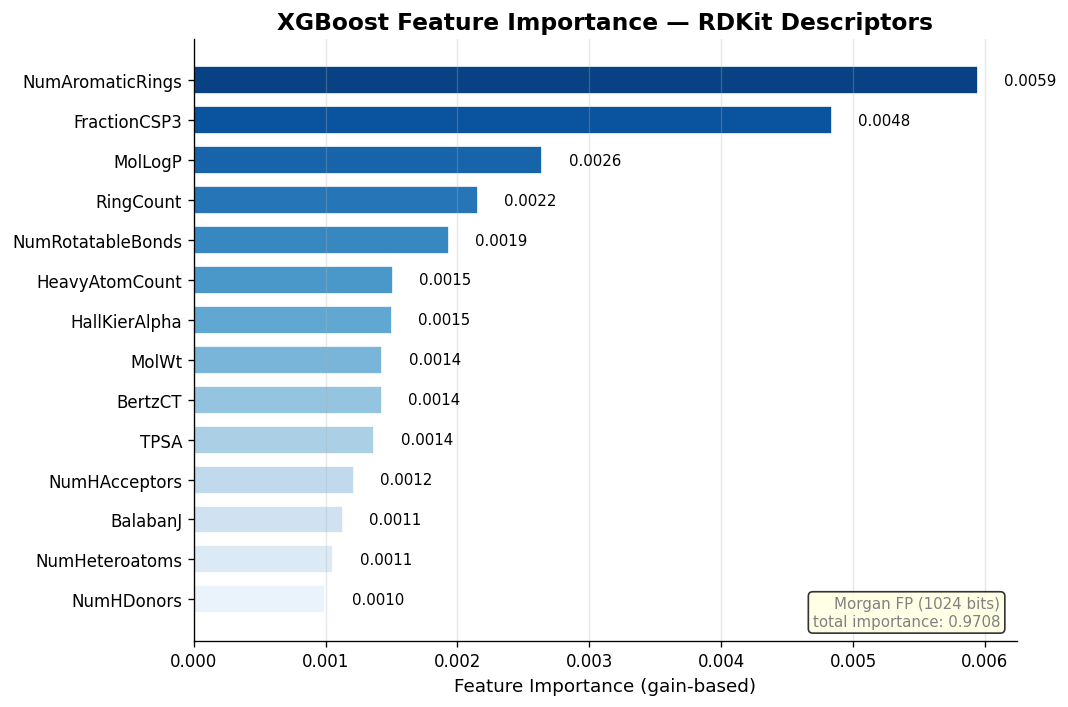


Top 5 most important descriptors:
          Feature  Importance
 NumAromaticRings    0.005945
     FractionCSP3    0.004838
          MolLogP    0.002643
        RingCount    0.002154
NumRotatableBonds    0.001932


In [15]:
# ── Section 9a: XGBoost Native Feature Importance ────────────────────────
# Focus on RDKit descriptor features (ignore individual FP bits)
importances = model.feature_importances_  # shape: (1038,)

# Aggregate fingerprint importance as one group
desc_imp = importances[:N_DESC]
fp_total = importances[N_DESC:].sum()

imp_df = pd.DataFrame({
    'Feature'   : DESCRIPTOR_NAMES,
    'Importance': desc_imp
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colors = sns.color_palette('Blues_r', len(imp_df))
bars = ax.barh(
    imp_df['Feature'], imp_df['Importance'],
    color=colors, edgecolor='white', height=0.7
)
ax.invert_yaxis()

# Annotate
for bar, val in zip(bars, imp_df['Importance']):
    ax.text(bar.get_width() + 0.0002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

# Add FP group annotation
ax.axvline(0, color='black', linewidth=0.5)
ax.text(0.98, 0.02,
        f'Morgan FP (1024 bits)\ntotal importance: {fp_total:.4f}',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=9, color='gray',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

ax.set_xlabel('Feature Importance (gain-based)', fontsize=11)
ax.set_title('XGBoost Feature Importance — RDKit Descriptors', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 most important descriptors:')
print(imp_df.head(5).to_string(index=False))

In [16]:
# ── Section 9b: SHAP Values ───────────────────────────────────────────────
print('⏳ Computing SHAP values (this may take a moment) …')

# Use a background sample for TreeExplainer (faster)
bg_size = min(200, len(X_train_pp))
bg_idx  = np.random.choice(len(X_train_pp), bg_size, replace=False)
X_bg    = X_train_pp[bg_idx]

explainer   = shap.TreeExplainer(model, data=X_bg, model_output='probability')

# Compute SHAP on the test set
shap_values = explainer.shap_values(X_test_pp)   # (N_test, 1038)

# ── Descriptor SHAP only ─────────────────────────────────────────────────
shap_desc = shap_values[:, :N_DESC]               # (N_test, 14)

print(f'✅ SHAP values computed. Shape: {shap_values.shape}')
print(f'   Descriptor SHAP slice: {shap_desc.shape}')

⏳ Computing SHAP values (this may take a moment) …


 96%|=================== | 1722/1794 [00:23<00:00]       

✅ SHAP values computed. Shape: (1794, 1038)
   Descriptor SHAP slice: (1794, 14)


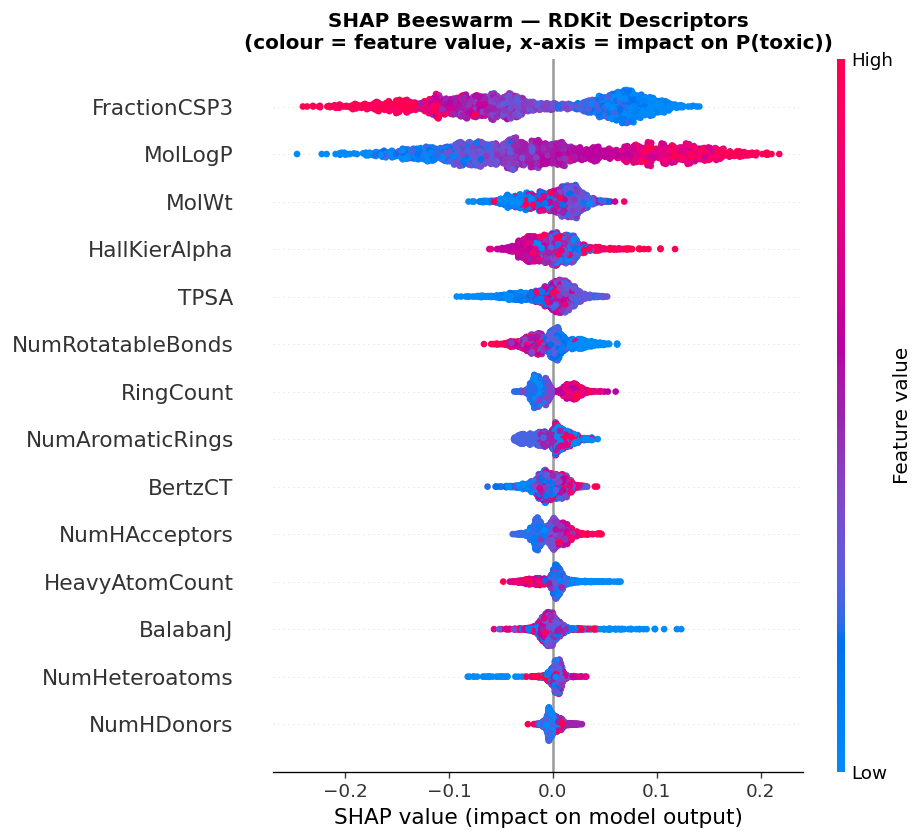

In [17]:
# ── SHAP Summary plot (beeswarm) — descriptors only ───────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_desc,
    features     = X_test_pp[:, :N_DESC],
    feature_names= DESCRIPTOR_NAMES,
    show         = False,
    plot_type    = 'dot',
    max_display  = 14,
    color_bar    = True,
)
plt.title('SHAP Beeswarm — RDKit Descriptors\n'
          '(colour = feature value, x-axis = impact on P(toxic))',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

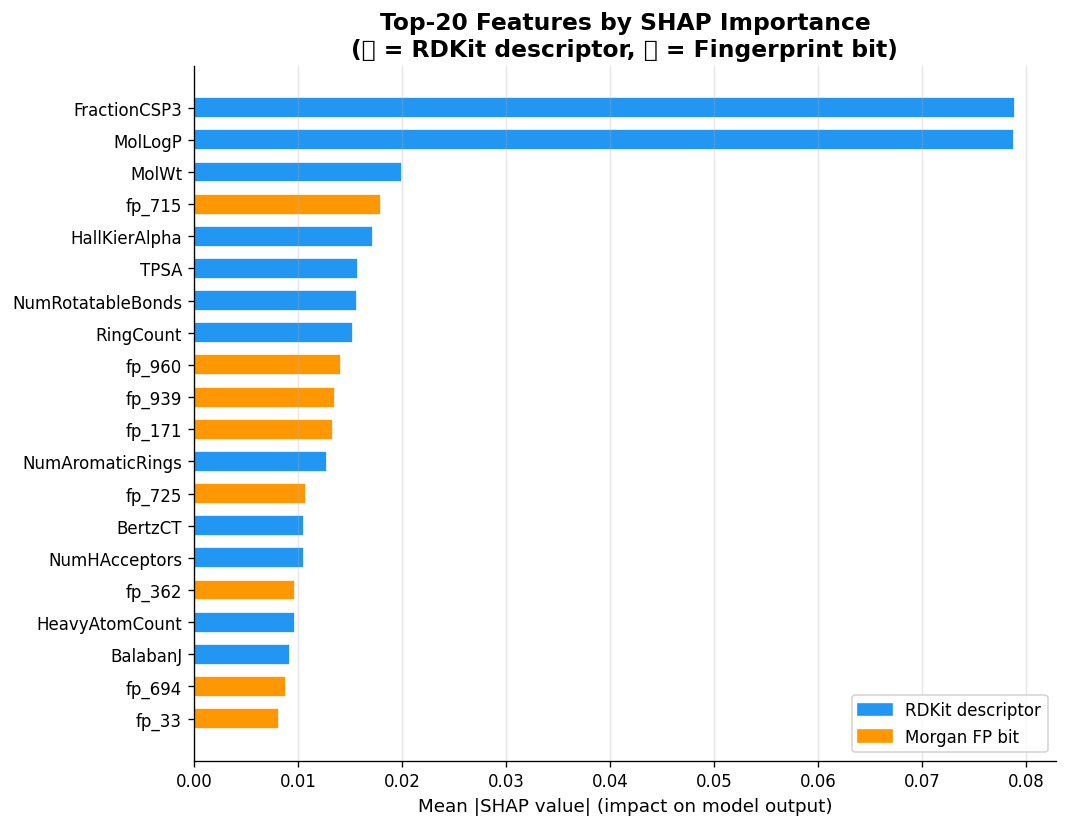


Top 10 features (by mean |SHAP|):
          Feature  Mean |SHAP|
     FractionCSP3     0.078917
          MolLogP     0.078828
            MolWt     0.020054
           fp_715     0.017999
    HallKierAlpha     0.017238
             TPSA     0.015769
NumRotatableBonds     0.015698
        RingCount     0.015267
           fp_960     0.014156
           fp_939     0.013610


In [18]:
# ── SHAP Bar plot (mean |SHAP|) — ALL features, top-20 ───────────────────
mean_abs_shap_all = np.abs(shap_values).mean(axis=0)   # (1038,)

# Build a named series
shap_series = pd.Series(mean_abs_shap_all, index=ALL_FEATURE_NAMES)

# Separate and aggregate
desc_shap_mean = shap_series[DESCRIPTOR_NAMES]
fp_shap_mean   = shap_series[FP_NAMES]

# Top-10 FP bits
top_fp = fp_shap_mean.nlargest(10).reset_index()
top_fp.columns = ['Feature', 'Mean |SHAP|']

# Combine for plot
plot_data = pd.concat([
    desc_shap_mean.reset_index().rename(columns={0: 'Mean |SHAP|',
                                                  'index': 'Feature'}),
    top_fp
], ignore_index=True).nlargest(20, 'Mean |SHAP|')

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#2196F3' if not f.startswith('fp_') else '#FF9800'
          for f in plot_data['Feature']]
bars = ax.barh(plot_data['Feature'], plot_data['Mean |SHAP|'],
               color=colors, edgecolor='white', height=0.65)
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP value| (impact on model output)', fontsize=11)
ax.set_title('Top-20 Features by SHAP Importance\n'
             '(🔵 = RDKit descriptor, 🟠 = Fingerprint bit)',
             fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#2196F3', label='RDKit descriptor'),
    Patch(color='#FF9800', label='Morgan FP bit'),
], loc='lower right')

plt.tight_layout()
plt.savefig('shap_bar_top20.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features (by mean |SHAP|):')
print(plot_data.head(10).to_string(index=False))

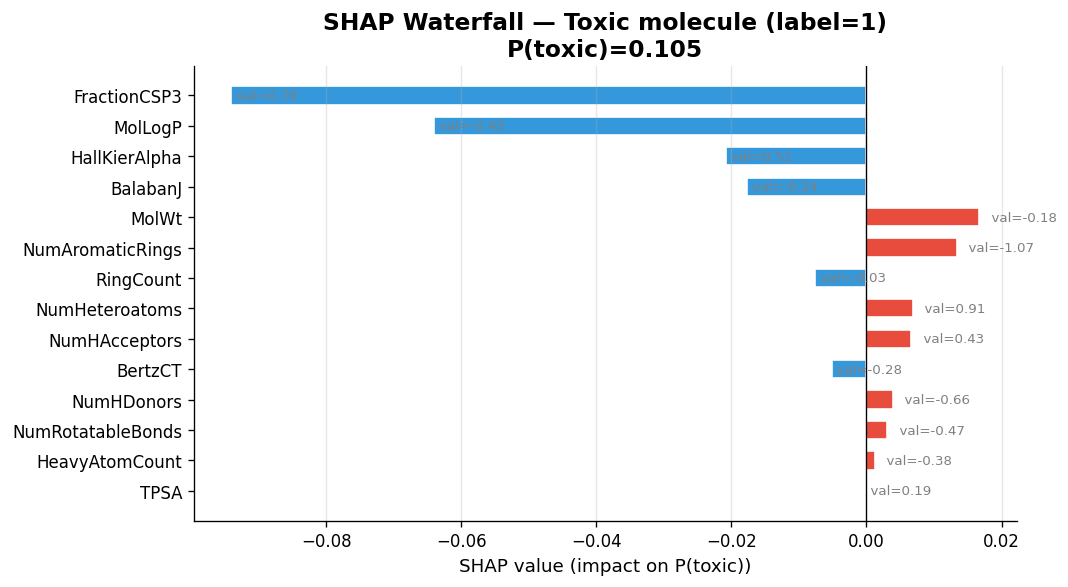

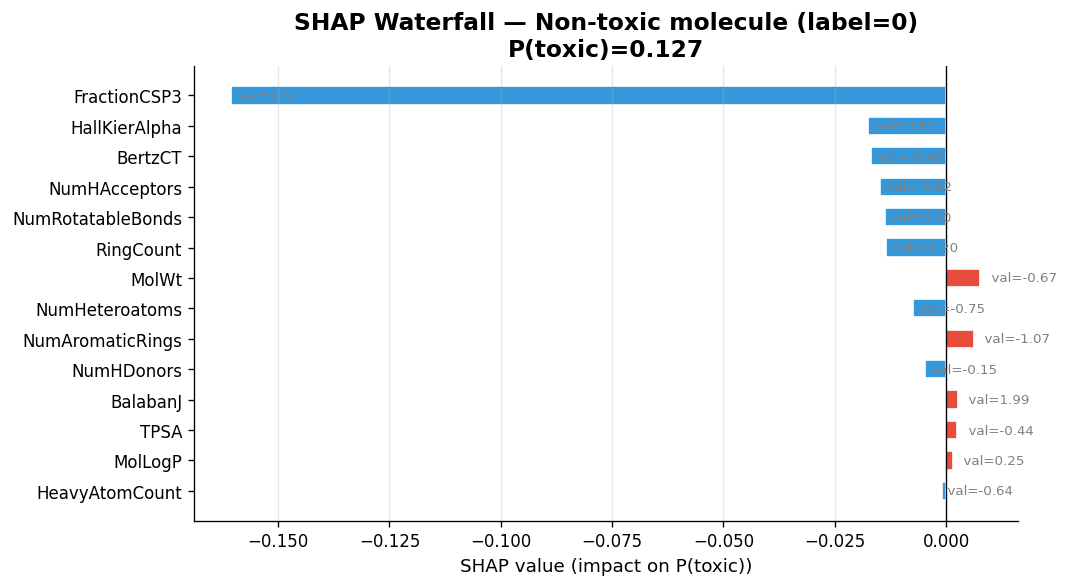

In [19]:
# ── SHAP Waterfall — single molecule example ───────────────────────────────
# Pick one toxic (1) and one non-toxic (0) molecule from the test set
idx_toxic     = np.where(y_test == 1)[0][0]
idx_nontoxic  = np.where(y_test == 0)[0][0]

for idx, title in [(idx_toxic, 'Toxic molecule (label=1)'),
                   (idx_nontoxic, 'Non-toxic molecule (label=0)')]:
    sv_desc = shap_desc[idx]          # SHAP values for descriptors
    vals    = X_test_pp[idx, :N_DESC] # scaled descriptor values

    contrib_df = pd.DataFrame({
        'Feature'   : DESCRIPTOR_NAMES,
        'SHAP value': sv_desc,
        'Feature val': vals,
    }).sort_values('SHAP value', key=abs, ascending=False)

    fig, ax = plt.subplots(figsize=(9, 5))
    colors  = ['#e74c3c' if v > 0 else '#3498db' for v in contrib_df['SHAP value']]
    ax.barh(contrib_df['Feature'], contrib_df['SHAP value'],
            color=colors, edgecolor='white', height=0.6)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.invert_yaxis()
    ax.set_xlabel('SHAP value (impact on P(toxic))', fontsize=11)
    ax.set_title(f'SHAP Waterfall — {title}\n'
                 f'P(toxic)={model.predict_proba([X_test_pp[idx]])[0,1]:.3f}',
                 fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    # Annotate with feature values
    for bar, fval in zip(ax.patches, contrib_df['Feature val']):
        ax.text(bar.get_width() + 0.0005 if bar.get_width() >= 0 else bar.get_width() - 0.0005,
                bar.get_y() + bar.get_height()/2,
                f'  val={fval:.2f}', va='center', fontsize=8, color='gray')

    plt.tight_layout()
    plt.savefig(f'shap_waterfall_{"toxic" if idx==idx_toxic else "nontoxic"}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

## 10. 🔮 Inference Function

In [20]:
def predict_smiles(
    smiles: str,
    threshold: float = 0.5,
    verbose: bool = True
) -> dict:
    """
    Predict Ames mutagenicity for a single SMILES string.

    Parameters
    ----------
    smiles    : str   — SMILES representation of the molecule
    threshold : float — classification threshold (default 0.5)
    verbose   : bool  — print a human-readable summary

    Returns
    -------
    dict with keys:
        smiles          : input SMILES
        valid           : whether SMILES was parseable
        probability     : P(mutagenic / toxic)
        predicted_class : 0 (non-toxic) or 1 (toxic)
        label           : 'Toxic' or 'Non-toxic'
        confidence      : max(P, 1-P) — certainty of the prediction
        descriptors     : dict of computed RDKit descriptor values
    """
    result = {
        'smiles'         : smiles,
        'valid'          : False,
        'probability'    : None,
        'predicted_class': None,
        'label'          : None,
        'confidence'     : None,
        'descriptors'    : {},
    }

    # ── 1. Parse SMILES ────────────────────────────────────────────────────
    mol = smiles_to_mol(smiles)
    if mol is None:
        if verbose:
            print(f'❌ Invalid SMILES: "{smiles}"')
        return result

    # ── 2. Compute descriptors ─────────────────────────────────────────────
    desc = mol_to_descriptors(mol)
    if np.isnan(desc).any():
        if verbose:
            print(f'❌ Could not compute descriptors for: "{smiles}"')
        return result

    fp   = mol_to_morgan_fp(mol)
    result['valid']       = True
    result['descriptors'] = dict(zip(DESCRIPTOR_NAMES, desc.tolist()))

    # ── 3. Assemble & scale ───────────────────────────────────────────────
    x_raw  = np.hstack([desc, fp.astype(np.float32)]).reshape(1, -1)
    x_proc = x_raw.copy()
    x_proc[:, :N_DESC] = scaler.transform(x_raw[:, :N_DESC])

    # ── 4. Predict ────────────────────────────────────────────────────────
    prob  = float(model.predict_proba(x_proc)[0, 1])
    cls   = int(prob >= threshold)
    conf  = max(prob, 1.0 - prob)
    label = 'Toxic (mutagenic)' if cls == 1 else 'Non-toxic'

    result.update({
        'probability'    : round(prob, 4),
        'predicted_class': cls,
        'label'          : label,
        'confidence'     : round(conf, 4),
    })

    # ── 5. Verbose output ─────────────────────────────────────────────────
    if verbose:
        icon = '☠️' if cls == 1 else '✅'
        bar_len   = 30
        filled    = int(prob * bar_len)
        prob_bar  = '█' * filled + '░' * (bar_len - filled)

        print(f'\n{icon}  Toxicity Prediction')
        print(f'   SMILES       : {smiles[:70]}{'...' if len(smiles)>70 else ''}')
        print(f'   Prediction   : {label}')
        print(f'   P(toxic)     : {prob:.4f}  |{prob_bar}| {prob*100:.1f}%')
        print(f'   Confidence   : {conf:.4f}')
        print(f'   Threshold    : {threshold}')
        print(f'   Key descriptors:')
        for k in ['MolWt', 'MolLogP', 'TPSA', 'NumAromaticRings', 'BertzCT']:
            print(f'     {k:<22}: {result["descriptors"][k]:.3f}')

    return result


print('✅ predict_smiles() is ready.')

✅ predict_smiles() is ready.


In [21]:
# ── Demo: test the inference function ─────────────────────────────────────
test_molecules = [
    # (name, SMILES)
    ('Aspirin',           'CC(=O)Oc1ccccc1C(=O)O'),
    ('Caffeine',          'Cn1cnc2c1c(=O)n(C)c(=O)n2C'),
    ('Aflatoxin B1',      'O=c1occc2c1cc1c(c2OC)c2c(cc1OC)OCO2'),
    ('Benzo[a]pyrene',    'C1=CC2=C3C=CC=CC3=C4C=CC=CC4=C2C=C1'),
    ('Sodium Chloride',   '[Na+].[Cl-]'),
    ('Invalid SMILES',    'NOT_A_SMILES_STRING!!!'),
]

print('=' * 60)
print('         INFERENCE FUNCTION DEMO')
print('=' * 60)

results_demo = []
for name, smi in test_molecules:
    print(f'\n── {name} ──')
    res = predict_smiles(smi, threshold=0.5, verbose=True)
    results_demo.append({'Molecule': name, **{
        k: res[k] for k in ['valid', 'predicted_class', 'probability', 'confidence', 'label']
    }})

print('\n\n📋 Summary Table:')
summary_df = pd.DataFrame(results_demo)
display(summary_df)

         INFERENCE FUNCTION DEMO

── Aspirin ──

✅  Toxicity Prediction
   SMILES       : CC(=O)Oc1ccccc1C(=O)O
   Prediction   : Non-toxic
   P(toxic)     : 0.3122  |█████████░░░░░░░░░░░░░░░░░░░░░| 31.2%
   Confidence   : 0.6878
   Threshold    : 0.5
   Key descriptors:
     MolWt                 : 180.159
     MolLogP               : 1.310
     TPSA                  : 63.600
     NumAromaticRings      : 1.000
     BertzCT               : 343.223

── Caffeine ──

✅  Toxicity Prediction
   SMILES       : Cn1cnc2c1c(=O)n(C)c(=O)n2C
   Prediction   : Non-toxic
   P(toxic)     : 0.3268  |█████████░░░░░░░░░░░░░░░░░░░░░| 32.7%
   Confidence   : 0.6732
   Threshold    : 0.5
   Key descriptors:
     MolWt                 : 194.194
     MolLogP               : -1.029
     TPSA                  : 61.820
     NumAromaticRings      : 2.000
     BertzCT               : 616.529

── Aflatoxin B1 ──

☠️  Toxicity Prediction
   SMILES       : O=c1occc2c1cc1c(c2OC)c2c(cc1OC)OCO2
   Prediction   : Toxic

,Molecule,valid,predicted_class,probability,confidence,label
0,Aspirin,True,0.0,0.3122,0.6878,Non-toxic
1,Caffeine,True,0.0,0.3268,0.6732,Non-toxic
2,Aflatoxin B1,True,1.0,0.9358,0.9358,Toxic (mutagenic)
3,Benzo[a]pyrene,True,1.0,0.9515,0.9515,Toxic (mutagenic)
4,Sodium Chloride,True,0.0,0.2216,0.7784,Non-toxic
5,Invalid SMILES,False,NaN,NaN,NaN,None


In [22]:
# ── Batch inference example ───────────────────────────────────────────────
def predict_batch(smiles_list: list, threshold: float = 0.5) -> pd.DataFrame:
    """
    Run predict_smiles() over a list of SMILES strings.
    Returns a tidy DataFrame with one row per molecule.
    """
    records = []
    for smi in smiles_list:
        res = predict_smiles(smi, threshold=threshold, verbose=False)
        records.append({
            'smiles'         : smi,
            'valid'          : res['valid'],
            'probability'    : res['probability'],
            'predicted_class': res['predicted_class'],
            'label'          : res['label'],
            'confidence'     : res['confidence'],
        })
    return pd.DataFrame(records)

# Example batch run
batch_smiles = [s for _, s in test_molecules]
batch_df = predict_batch(batch_smiles)

print('Batch prediction results:')
display(batch_df)

Batch prediction results:


,smiles,valid,probability,predicted_class,label,confidence
0,CC(=O)Oc1ccccc1C(=O)O,True,0.3122,0.0,Non-toxic,0.6878
1,Cn1cnc2c1c(=O)n(C)c(=O)n2C,True,0.3268,0.0,Non-toxic,0.6732
2,O=c1occc2c1cc1c(c2OC)c2c(cc1OC)OCO2,True,0.9358,1.0,Toxic (mutagenic),0.9358
3,C1=CC2=C3C=CC=CC3=C4C=CC=CC4=C2C=C1,True,0.9515,1.0,Toxic (mutagenic),0.9515
4,[Na+].[Cl-],True,0.2216,0.0,Non-toxic,0.7784
5,NOT_A_SMILES_STRING!!!,False,NaN,NaN,None,NaN


## 11. 💾 Save Artefacts

In [23]:
import pickle, json

SAVE_DIR = 'combined_model_artefacts'
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. XGBoost model
model.save_model(f'{SAVE_DIR}/xgboost_ames.json')

# 2. Scaler
with open(f'{SAVE_DIR}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 3. Feature metadata
metadata = {
    'descriptor_names': DESCRIPTOR_NAMES,
    'n_descriptors'   : N_DESC,
    'fp_bits'         : FP_BITS,
    'fp_radius'       : FP_RADIUS,
    'all_feature_names': ALL_FEATURE_NAMES,
    'best_iteration'  : int(best_iter),
    'test_metrics'    : {k: round(v, 4) for k, v in metrics.items()},
    'random_seed'     : RANDOM_SEED,
}
with open(f'{SAVE_DIR}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'✅ Artefacts saved to ./{SAVE_DIR}/')
for fname in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(f'{SAVE_DIR}/{fname}') / 1024
    print(f'   {fname:<30} {size:>8.1f} KB')

print('\nTest set performance summary:')
for k, v in metrics.items():
    print(f'   {k:<12}: {v:.4f}')

✅ Artefacts saved to ./combined_model_artefacts/
   metadata.json                      14.7 KB
   scaler.pkl                          0.8 KB
   xgboost_ames.json                1163.2 KB

Test set performance summary:
   Accuracy    : 0.7692
   Precision   : 0.7707
   Recall      : 0.7211
   F1-Score    : 0.7451
   ROC-AUC     : 0.8466


---
## 📝 Summary

| Component | Details |
|-----------|--------|
| **Featuriser** | 14 RDKit descriptors + Morgan ECFP4 (1024 bits) = 1038 features |
| **Scaler** | `StandardScaler` on descriptors only; FP bits left as binary |
| **Model** | `XGBClassifier` with early stopping on validation AUC |
| **Splits** | 70% train / 15% val / 15% test (stratified) |
| **Explainability** | SHAP TreeExplainer — beeswarm + waterfall plots |
| **Inference** | `predict_smiles(smiles)` → probability + class + descriptors |
| **Artefacts** | Model JSON + scaler PKL + metadata JSON saved to disk |

### Key RDKit Descriptors used
```
Physicochemical : MolWt, MolLogP, TPSA, NumHDonors, NumHAcceptors, NumRotatableBonds
Structural      : RingCount, FractionCSP3, HeavyAtomCount, NumHeteroatoms, NumAromaticRings
Topological     : BertzCT, BalabanJ, HallKierAlpha
Fingerprint     : Morgan (ECFP4, radius=2, nBits=1024)
```

### Quickstart (after training)
```python
result = predict_smiles('C1=CC2=C3C=CC=CC3=C4C=CC=CC4=C2C=C1')  # Benzo[a]pyrene
print(result['label'], result['probability'])
```
